# Лабораторная работа № 1
**Студент:** Заречкин Артём, гр. Б24-507  
**Вариант:** 14 — функция Стыблинского—Танга, $d=7$

Цель: реализовать базовый генетический алгоритм для непрерывной многомерной оптимизации и провести воспроизводимое сравнение с базовой случайной выборкой при одинаковом вычислительном бюджете.


In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка конфигурации. В Colab положите config.json рядом с notebook.
config_path = Path('config.json')
if config_path.exists():
    CFG = json.loads(config_path.read_text(encoding='utf-8'))
else:
    # Резервные значения, совпадающие с приложенным config.json
    CFG = {
        'student': 'Заречкин Артём', 'group': 'Б24-507',
        'variant': 14, 'function': 'Styblinski-Tang', 'd': 7,
        'bounds': [-5, 5], 'population_size': 50, 'population_states': 100,
        'evaluation_budget': 5000, 'crossover_rate': 0.8,
        'mutation_rate': 0.2, 'mutation_sigma': 0.5,
        'comparison_mutation_sigma': 0.2, 'tournament_size': 3,
        'elitism_count': 1, 'runs': 20, 'base_seed': 42
    }

D = CFG['d']
BOUNDS = tuple(CFG['bounds'])
POP_SIZE = CFG['population_size']
STATES = CFG['population_states']
BUDGET = CFG['evaluation_budget']
PC = CFG['crossover_rate']
PM = CFG['mutation_rate']
SIGMA = CFG['mutation_sigma']
SIGMA_ALT = CFG['comparison_mutation_sigma']
TOURNAMENT = CFG['tournament_size']
RUNS = CFG['runs']
BASE_SEED = CFG['base_seed']

assert POP_SIZE * STATES == BUDGET, 'Для честного бюджета POP_SIZE * population_states должно равняться evaluation_budget.'
print(CFG)


{'student': 'Заречкин Артём', 'group': 'Б24-507', 'variant': 14, 'function': 'Styblinski-Tang', 'd': 7, 'bounds': [-5, 5], 'population_size': 50, 'population_states': 100, 'evaluation_budget': 5000, 'initialization': 'uniform', 'selection': 'tournament', 'tournament_size': 3, 'crossover': 'arithmetic', 'crossover_rate': 0.8, 'mutation': 'gaussian_per_individual', 'mutation_rate': 0.2, 'mutation_sigma': 0.5, 'comparison_mutation_sigma': 0.2, 'boundary_handling': 'clipping', 'elitism_count': 1, 'stopping_criterion': 'evaluation_budget', 'runs': 20, 'base_seed': 42}


## Реализация генетического алгоритма

- **Генотип:** вещественный вектор $x=(x_1,\dots,x_7)$.
- **Фенотип:** тот же вектор, то есть точка пространства поиска; отдельное декодирование не требуется.
- **Инициализация:** независимая равномерная выборка каждой координаты из $[-5,5]$.
- **Селекция:** турнирная, размер турнира 3.
- **Кроссовер:** арифметический, вероятность 0.8.
- **Мутация:** гауссовская; с вероятностью 0.2 мутирует особь, ко всем её генам добавляется $N(0,\sigma)$.
- **Ограничения:** clipping в $[-5,5]$.
- **Элитизм:** одна лучшая особь переносится в следующее состояние популяции без изменений.
- **Критерий остановки:** ровно 5000 вычислений целевой функции: 50 оценок начальной популяции + 99 × 50 оценок потомков.


In [2]:
def fitness(x):
    x = np.asarray(x, dtype=float)
    return 0.5 * np.sum(x**4 - 16*x**2 + 5*x)


def init_population(rng, size=POP_SIZE):
    return rng.uniform(BOUNDS[0], BOUNDS[1], size=(size, D))


def evaluate(pop):
    return np.array([fitness(ind) for ind in pop], dtype=float)


def tournament_select(rng, pop, fits):
    selected = []
    for _ in range(len(pop)):
        idx = rng.choice(len(pop), TOURNAMENT, replace=False)
        winner = idx[np.argmin(fits[idx])]
        selected.append(pop[winner].copy())
    return np.asarray(selected)


def arithmetic_crossover(rng, pop):
    offspring = []
    for i in range(0, len(pop), 2):
        p1 = pop[i]
        p2 = pop[(i + 1) % len(pop)]
        if rng.random() < PC:
            alpha = rng.random()
            c1 = alpha * p1 + (1 - alpha) * p2
            c2 = alpha * p2 + (1 - alpha) * p1
        else:
            c1, c2 = p1.copy(), p2.copy()
        offspring.extend([c1, c2])
    return np.asarray(offspring[:len(pop)])


def gaussian_mutation(rng, pop, sigma):
    mutated = pop.copy()
    for i in range(len(mutated)):
        if rng.random() < PM:
            mutated[i] += rng.normal(0.0, sigma, size=D)
    return np.clip(mutated, BOUNDS[0], BOUNDS[1])


def ga_run(seed, sigma=SIGMA):
    rng = np.random.default_rng(seed)
    pop = init_population(rng)
    fits = evaluate(pop)
    evaluations = len(pop)

    best_idx = int(np.argmin(fits))
    best_fit = float(fits[best_idx])
    best_x = pop[best_idx].copy()
    history = [best_fit]  # состояние 0: начальная популяция

    # Ещё 99 состояний популяции: всего 100 * 50 = 5000 оценок
    for _ in range(1, STATES):
        elite_idx = int(np.argmin(fits))
        elite = pop[elite_idx].copy()

        parents = tournament_select(rng, pop, fits)
        offspring = arithmetic_crossover(rng, parents)
        offspring = gaussian_mutation(rng, offspring, sigma)
        offspring[0] = elite

        pop = offspring
        fits = evaluate(pop)
        evaluations += len(pop)

        idx = int(np.argmin(fits))
        if fits[idx] < best_fit:
            best_fit = float(fits[idx])
            best_x = pop[idx].copy()
        history.append(best_fit)

    assert evaluations == BUDGET
    return np.asarray(history), best_fit, best_x, evaluations


def random_search_run(seed):
    rng = np.random.default_rng(seed)
    samples = rng.uniform(BOUNDS[0], BOUNDS[1], size=(BUDGET, D))
    fits = np.array([fitness(x) for x in samples])
    idx = int(np.argmin(fits))
    return float(fits[idx]), samples[idx].copy(), BUDGET


## Эксперименты

Проводятся 20 независимых запусков с seed 42–61. Сравниваются:

1. базовый ГА с $\sigma=0.5$;
2. ГА с изменённым **только одним фактором** — масштабом мутации $\sigma=0.2$;
3. случайная выборка при том же бюджете 5000 вычислений функции.


In [3]:
seeds = list(range(BASE_SEED, BASE_SEED + RUNS))

base_histories = []
alt_histories = []
rows = []

for run_no, seed in enumerate(seeds, start=1):
    h_base, f_base, x_base, evals_base = ga_run(seed, sigma=SIGMA)
    h_alt, f_alt, x_alt, evals_alt = ga_run(seed, sigma=SIGMA_ALT)
    f_rs, x_rs, evals_rs = random_search_run(seed)

    base_histories.append(h_base)
    alt_histories.append(h_alt)

    row = {
        'run': run_no,
        'seed': seed,
        'evaluations': BUDGET,
        'ga_sigma_0_5_best': f_base,
        'ga_sigma_0_2_best': f_alt,
        'random_search_best': f_rs,
    }
    for j, value in enumerate(x_base, start=1):
        row[f'ga_sigma_0_5_x{j}'] = value
    rows.append(row)

results = pd.DataFrame(rows)
results.to_csv('results.csv', index=False)
results.head()


,run,seed,evaluations,ga_sigma_0_5_best,ga_sigma_0_2_best,random_search_best,ga_sigma_0_5_x1,ga_sigma_0_5_x2,ga_sigma_0_5_x3,ga_sigma_0_5_x4,ga_sigma_0_5_x5,ga_sigma_0_5_x6,ga_sigma_0_5_x7
0,1,42,5000,-245.100411,-245.837707,-209.348512,-3.006822,-2.875335,-2.819342,2.797200,2.617264,-3.007619,-2.901880
1,2,43,5000,-231.064726,-231.562514,-233.367655,-2.739251,2.684726,-2.965236,2.673652,2.708436,-2.874577,-2.876071
2,3,44,5000,-258.799968,-259.904292,-207.465094,2.631932,-2.910875,-2.946113,-2.765897,-2.725912,-2.861746,-2.807937
3,4,45,5000,-258.970625,-245.811798,-219.627459,-2.737157,-2.936993,-2.895572,-2.889665,-2.837835,2.588205,-2.805725
4,5,46,5000,-217.203305,-217.504608,-217.886675,-2.897810,-2.904400,2.748154,-2.882487,2.806554,2.674934,2.605272


In [4]:
def summary(values):
    values = np.asarray(values, dtype=float)
    return {
        'best': float(np.min(values)),
        'mean': float(np.mean(values)),
        'median': float(np.median(values)),
        'std': float(np.std(values, ddof=1)),
        'worst': float(np.max(values)),
    }

summaries = {
    'GA, sigma=0.5': summary(results['ga_sigma_0_5_best']),
    'GA, sigma=0.2': summary(results['ga_sigma_0_2_best']),
    'Random Search': summary(results['random_search_best']),
}
summary_df = pd.DataFrame(summaries).T
summary_df.index.name = 'method'
summary_df.to_csv('summary.csv')
print(summary_df.round(6))


                     best        mean      median        std       worst
method                                                                  
GA, sigma=0.5 -259.727358 -248.047312 -245.672598  11.770072 -217.203305
GA, sigma=0.2 -260.002507 -245.739068 -245.787764  12.130494 -217.504608
Random Search -240.828135 -226.043523 -226.353337  10.476712 -207.465094


In [5]:
# Теоретический минимум: стационарная точка одномерной функции,
# соответствующая глобальному минимуму на [-5, 5].
roots = np.roots([2.0, 0.0, -16.0, 2.5])  # 2x^3 - 16x + 2.5 = 0
real_roots = np.real(roots[np.isreal(roots)])
x_star_1d = float(real_roots[np.argmin([fitness(np.array([r])) for r in real_roots])])
f_star_1d = 0.5 * (x_star_1d**4 - 16*x_star_1d**2 + 5*x_star_1d)
f_star = D * f_star_1d
print(f'x* (для каждой координаты) ≈ {x_star_1d:.9f}')
print(f'f* для d={D} ≈ {f_star:.9f}')


x* (для каждой координаты) ≈ -2.903534028
f* для d=7 ≈ -274.163159926


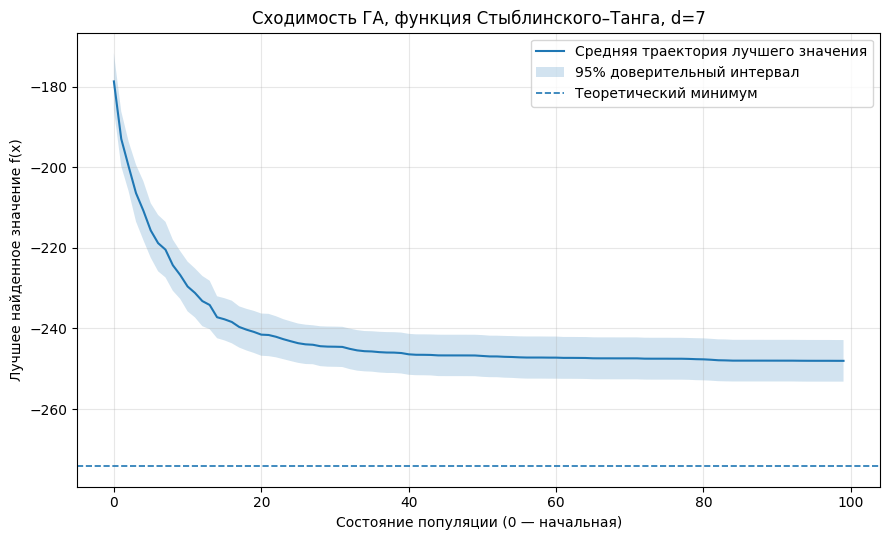

In [6]:
# График сходимости базового ГА по 20 запускам: средняя траектория и 95% ДИ
H = np.asarray(base_histories)
mean_h = H.mean(axis=0)
se_h = H.std(axis=0, ddof=1) / np.sqrt(RUNS)
ci = 1.96 * se_h
x = np.arange(STATES)

plt.figure(figsize=(9, 5.5))
plt.plot(x, mean_h, label='Средняя траектория лучшего значения')
plt.fill_between(x, mean_h-ci, mean_h+ci, alpha=0.2, label='95% доверительный интервал')
plt.axhline(f_star, linestyle='--', linewidth=1.2, label='Теоретический минимум')
plt.xlabel('Состояние популяции (0 — начальная)')
plt.ylabel('Лучшее найденное значение f(x)')
plt.title('Сходимость ГА, функция Стыблинского–Танга, d=7')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('convergence.png', dpi=180)
plt.show()


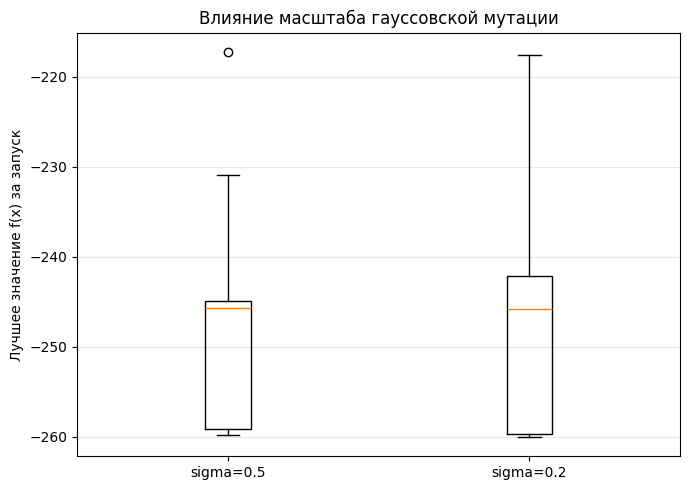

In [7]:
# Сравнение двух конфигураций, отличающихся только sigma
comparison = pd.DataFrame({
    'sigma=0.5': results['ga_sigma_0_5_best'],
    'sigma=0.2': results['ga_sigma_0_2_best'],
})

plt.figure(figsize=(7, 5))
plt.boxplot([comparison['sigma=0.5'], comparison['sigma=0.2']], tick_labels=['sigma=0.5', 'sigma=0.2'])
plt.ylabel('Лучшее значение f(x) за запуск')
plt.title('Влияние масштаба гауссовской мутации')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('parameter_comparison.png', dpi=180)
plt.show()


In [8]:
# Краткий автоматический вывод для проверки сдаваемых результатов
base = summaries['GA, sigma=0.5']
alt = summaries['GA, sigma=0.2']
rs = summaries['Random Search']

print(f"Базовый ГА: mean={base['mean']:.4f}, median={base['median']:.4f}, best={base['best']:.4f}, worst={base['worst']:.4f}")
print(f"ГА sigma=0.2: mean={alt['mean']:.4f}, median={alt['median']:.4f}, best={alt['best']:.4f}, worst={alt['worst']:.4f}")
print(f"Random Search: mean={rs['mean']:.4f}, median={rs['median']:.4f}, best={rs['best']:.4f}, worst={rs['worst']:.4f}")
print(f"Все методы используют одинаковый бюджет: {BUDGET} вычислений функции на запуск.")


Базовый ГА: mean=-248.0473, median=-245.6726, best=-259.7274, worst=-217.2033
ГА sigma=0.2: mean=-245.7391, median=-245.7878, best=-260.0025, worst=-217.5046
Random Search: mean=-226.0435, median=-226.3533, best=-240.8281, worst=-207.4651
Все методы используют одинаковый бюджет: 5000 вычислений функции на запуск.
